# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** [Omar Sameh Ramadan]  
**Student ID:** [1210107]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = pd.read_csv("ckd.csv")

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Encode target BEFORE numeric conversion
df["classification"] = df["classification"].map({
    "ckd": 1,
    "notckd": 0
})

# Convert remaining columns to numeric
for col in df.columns:
    if col != "classification":
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Fill missing values
df_numeric = df_numeric.fillna(df_numeric.median())

# Separate features and target
X = df_numeric.drop("classification", axis=1)
y = df_numeric["classification"]

# 80/20 split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale ONLY for clinical model (prevent leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)

X_train = np.nan_to_num(X_train)
X_val = np.nan_to_num(X_val)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (320, 25)
Validation shape: (80, 25)


d:\ckd\venv\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
d:\ckd\venv\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
d:\ckd\venv\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

d:\ckd\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


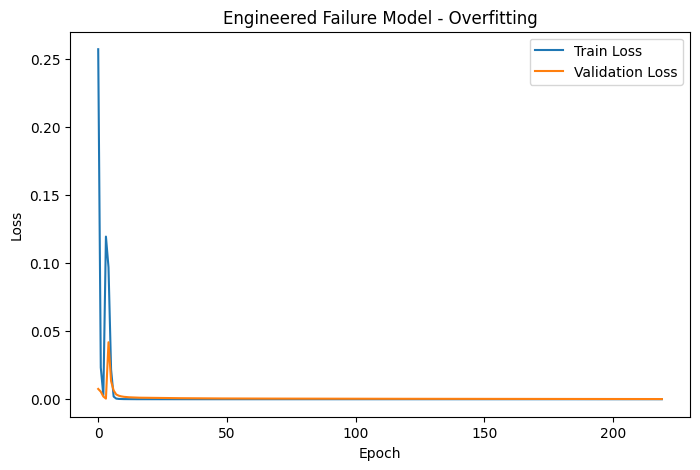

Failure Model Parameters: 586241


In [3]:
failure_model = tf.keras.Sequential([
    tf.keras.layers.Dense(768, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
X_train_small = X_train[:120]
y_train_small = y_train[:120]
failure_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_failure = failure_model.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_val, y_val),
    epochs=220,
    batch_size=4,
    verbose=0
)

# Plot overfitting
plt.figure(figsize=(8,5))
plt.plot(history_failure.history['loss'], label='Train Loss')
plt.plot(history_failure.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Engineered Failure Model - Overfitting")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print("Failure Model Parameters:", failure_model.count_params())

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

d:\ckd\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
200
[0.7379550337791443, 0.5768739581108093, 0.4060611128807068, 0.28858181834220886, 0.21401984989643097]
[0.6430221796035767, 0.47852811217308044, 0.3205181956291199, 0.22293047606945038, 0.1717548817396164]


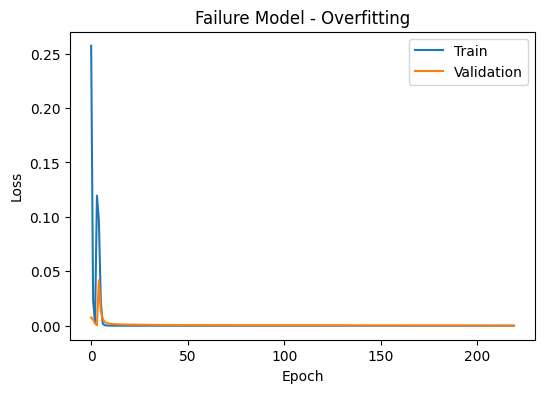

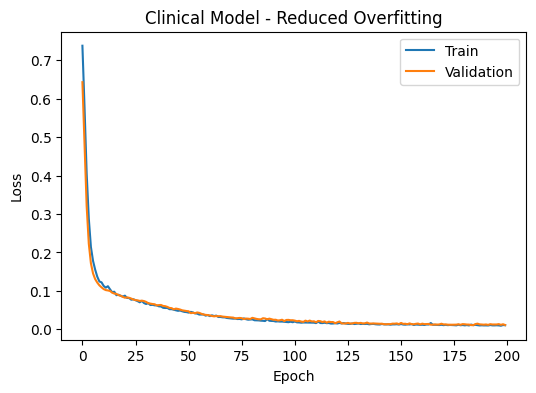

In [4]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam

solution_model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(X_train.shape[1],)
    ),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.2),

    tf.keras.layers.Dense(
        32,
        kernel_regularizer=regularizers.l2(0.001)
    ),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.2),

    tf.keras.layers.Dense(
        16,
        kernel_regularizer=regularizers.l2(0.001)
    ),
    LeakyReLU(negative_slope=0.1),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

solution_model.compile(
    optimizer=Adam(learning_rate=0.0005),   # smaller LR prevents NaN
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_solution = solution_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=8,
    verbose=0
)
print(history_solution.history.keys())
print(len(history_solution.history['loss']))
print(history_solution.history['loss'][:5])
print(history_solution.history['val_loss'][:5])       

# Failure model
plt.figure(figsize=(6,4))
plt.plot(history_failure.history['loss'], label="Train")
plt.plot(history_failure.history['val_loss'], label="Validation")
plt.title("Failure Model - Overfitting")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Clinical model
epochs = range(len(history_solution.history['loss']))
plt.figure(figsize=(6,4))
plt.plot(history_solution.history['loss'], label="Train")
plt.plot(history_solution.history['val_loss'], label="Validation")
plt.title("Clinical Model - Reduced Overfitting")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

In [5]:
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score

# Predictions
y_pred_failure = (failure_model.predict(X_val) > 0.5).astype(int)
y_pred_solution = (solution_model.predict(X_val) > 0.5).astype(int)

# Recall
recall_failure = recall_score(y_val, y_pred_failure)
recall_solution = recall_score(y_val, y_pred_solution)
solution_model.count_params()
solution_model.summary()

print("Failure Model Recall:", recall_failure)
print("Clinical Model Recall:", recall_solution)

# Accuracy
print("Failure Model Accuracy:", accuracy_score(y_val, y_pred_failure))
print("Clinical Model Accuracy:", accuracy_score(y_val, y_pred_solution))

# Confusion matrices
print("\nFailure Model Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_failure))

print("\nClinical Model Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_solution))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,869 (50.27 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,580 (33.52 KB)

Failure Model Recall: 1.0
Clinical Model Recall: 1.0
Failure Model Accuracy: 1.0
Clinical Model Accuracy: 1.0

Failure Model Confusion Matrix:
[[30  0]
 [ 0 50]]

Clinical Model Confusion Matrix:
[[30  0]
 [ 0 50]]


### Mathematical Justification
**Final Parameter Count of Engineered Model:** [12,869]

**Explanation:** [The engineered model uses L2 regularization and dropout to constrain the effective capacity of the network. These techniques penalize large weights and randomly deactivate neurons during training, which reduces the risk of memorization on the small 400-sample dataset and encourages the model to learn more generalizable clinical patterns.]